[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_02/TSA_ch2_ma_models/TSA_ch2_ma_models.ipynb)

# TSA_ch2_ma_models

Moving-average models: MA(1) paths with theta = 0.8 and -0.8, sample and theoretical ACF (cut-off after lag 1) and PACF (gradual decay); rho(1) = theta/(1 + theta^2) as a function of theta, its maximum 0.5 and the identification problem of theta and 1/theta (invertibility).

*Time Series Analysis (TSA), Chapter 2: ARMA models. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_02/TSA_ch2_ma_models


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # default size about 7 inches wide (as in MFM); a chart is shown 11-13 cm wide on a slide, so these font sizes
    # give 7-9 pt text there. Multi-panel charts should stay near 7-7.6 inches wide: at 10-11 inches the axis
    # text drops to about 5 pt on the slide.
    rc['figure.figsize'] = (7.0, 3.4)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [5]:
from statsmodels.tsa.stattools import acf, pacf

from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.arima_process import ArmaProcess

from statsmodels.regression.linear_model import yule_walker

SEED = 2026

GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')

GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')

HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')

GDP_START = '2000-01-01'

INFL_START = '2005-01-01'

BAND_COL = st.IDAred

MODELS = {'AR(2)': ([1.0, -0.6], []), 'MA(2)': ([], [0.6, 0.3]), 'ARMA(1,1)': ([0.7], [0.4])}

HERE = "."

def ro_gdp_growth(kind='yoy', start=GDP_START):
    """Romanian real GDP growth in %: 'yoy' = 100 (ln Y_t - ln Y_{t-4}) of the unadjusted series,
    'qoq' = 100 (ln Y_t - ln Y_{t-1}) of the seasonally adjusted series."""
    if kind == 'yoy':
        y = 100 * np.log(read_eurostat(*GDP_NSA)).diff(4)
    else:
        y = 100 * np.log(read_eurostat(*GDP_SCA)).diff()
    y = y.dropna().loc[start:]
    y.index.freq = None
    return y.rename(f'gdp_{kind}')


def ro_inflation(start=INFL_START):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    p = read_eurostat(*HICP)
    return (100 * np.log(p).diff(12)).dropna().loc[start:].rename('inflation')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (Chapter 1)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10, df=None):
    """Ljung-Box Q*(m) with its p-value from chi2(df); df = m by default, m - p - q for ARMA residuals."""
    x = np.asarray(x, float)
    T = len(x)
    r = sample_acf(x, m)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    df = m if df is None else df
    return {'lb': float(q), 'df': int(df), 'lb_p': float(stats.chi2.sf(q, df))}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample', band=True, theory_label='theoretical'):
    """Bars at lags 1..len(r), the +-1.96/sqrt(T) band and optional theoretical values (dots)."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label=theory_label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, mu=0.0, burn=500, rng=None):
    """X_t - mu = sum phi_i (X_{t-i} - mu) + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return mu + x[burn:]


def arma_process(phi=(), theta=()):
    """statsmodels ArmaProcess for X_t = phi_1 X_{t-1} + ... + e_t + theta_1 e_{t-1} + ... (signs as in the slides)."""
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)])


def theoretical_acf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).acf(nlags + 1)[1:]


def theoretical_pacf(phi=(), theta=(), nlags=20):
    return arma_process(phi, theta).pacf(nlags + 1)[1:]


def psi_weights(phi=(), theta=(), n=20):
    """psi_0, ..., psi_{n-1} of the causal representation X_t = sum psi_j e_{t-j}:
    psi_j = theta_j + sum_{i=1}^{min(j,p)} phi_i psi_{j-i}, psi_0 = 1."""
    p, q = len(phi), len(theta)
    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        psi[j] = (theta[j - 1] if j <= q else 0.0) + sum(phi[i] * psi[j - 1 - i] for i in range(min(j, p)))
    return psi


def inverse_roots(phi):
    """Inverse roots of 1 - phi_1 z - ... - phi_p z^p (stationary iff all have modulus < 1)."""
    roots = np.roots(np.r_[-np.asarray(phi, float)[::-1], 1.0])
    return 1 / roots


def fit_arma(x, p, q, trend='c'):
    """Gaussian maximum likelihood (statsmodels state-space ARIMA)."""
    return ARIMA(np.asarray(x, float), order=(p, 0, q), trend=trend).fit()


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def fig_ma1(n=300, nlags=12, save_it=True):
    """MA(1) with theta = 0.8 and -0.8: paths, sample ACF (cuts off after lag 1) and sample PACF (decays)."""
    rng = np.random.default_rng(SEED + 1)
    e = rng.normal(size=n + 1)
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.6))
    out = {}
    for i, (th, c) in enumerate([(0.8, st.MainBlue), (-0.8, st.IDAred)]):
        x = e[1:] + th * e[:-1]
        ax[i, 0].plot(x, color=c, lw=0.7)
        ax[i, 0].set_title(rf'MA(1), $\theta = {th}$')
        ax[i, 0].set_ylim(-5, 5)
        r, pc = sample_acf(x, nlags), sample_pacf(x, nlags)
        acf_bars(ax[i, 1], r, n, color=c, theory=theoretical_acf(theta=[th], nlags=nlags),
                 label='sample' if i == 0 else '_nolegend_', theory_label='theoretical' if i == 0 else '_nolegend_')
        acf_bars(ax[i, 2], pc, n, color=c, theory=theoretical_pacf(theta=[th], nlags=nlags), label='_nolegend_',
                 theory_label='_nolegend_')
        for a in ax[i, 1:]:
            a.set_ylim(-0.65, 0.65)
            if i == 1:
                a.get_lines()[1].set_label('_nolegend_')
        ax[i, 1].set_title('ACF')
        ax[i, 2].set_title('PACF')
        out[str(th)] = {'r1': float(r[0]), 'r2': float(r[1]), 'p1': float(pc[0]), 'p2': float(pc[1]),
                        'p3': float(pc[2]), 'rho1_th': th / (1 + th ** 2)}
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch2_ma1', save_it)
    return out


def fig_ma1_rho(save_it=True):
    """rho(1) = theta / (1 + theta^2) of an MA(1): maximum 0.5 at theta = 1; theta and 1/theta give the same rho(1)."""
    th = np.linspace(-4, 4, 801)
    r = th / (1 + th ** 2)
    fig, ax = plt.subplots(figsize=(8.6, 3.3))
    ax.plot(th, r, color=st.MainBlue, lw=1.6, label=r'$\rho(1) = \theta/(1 + \theta^2)$')
    ax.axhline(0.5, color=st.IDAred, ls='--', lw=0.9, label=r'$\pm 0.5$: the largest possible $|\rho(1)|$')
    ax.axhline(-0.5, color=st.IDAred, ls='--', lw=0.9, label='_nolegend_')
    ax.axvspan(-1, 1, color=st.Forest, alpha=0.10, label=r'invertible: $|\theta| < 1$')
    for t0, c in [(0.5, st.Orange), (2.0, st.Purple)]:
        ax.plot(t0, t0 / (1 + t0 ** 2), 'o', ms=8, color=c, label=rf'$\theta = {t0}$: $\rho(1) = 0.4$')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel(r'$\theta$')
    ax.set_title(r'MA(1): $\theta$ and $1/\theta$ give the same autocorrelation')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('tsa_ch2_ma1_rho', save_it)
    return {'r05': 0.5 / 1.25, 'r2': 2 / 5}

## Run

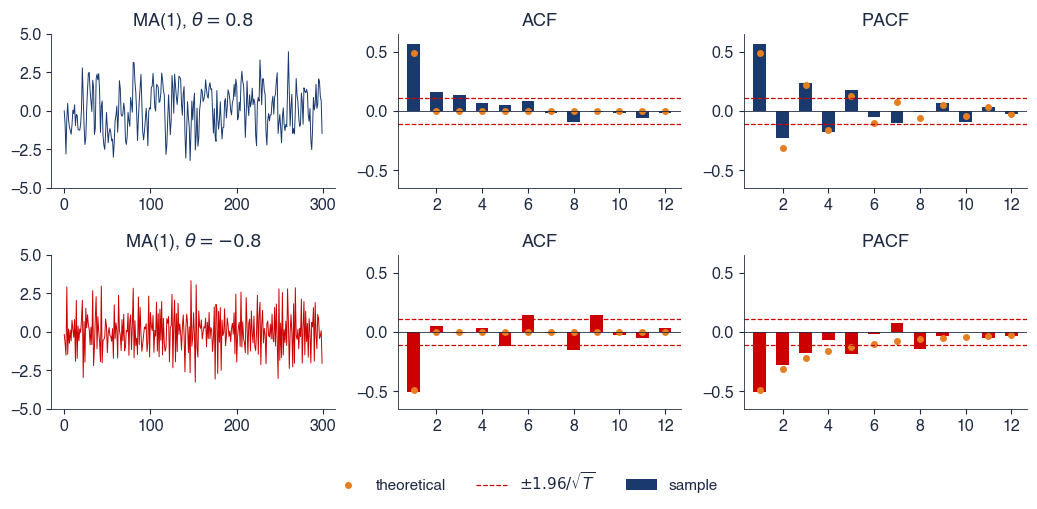

{'0.8': {'r1': 0.5619630011459609, 'r2': 0.15677309636023787, 'p1': 0.5619630011459609, 'p2': -0.23243186135625932, 'p3': 0.23883720195593283, 'rho1_th': 0.4878048780487805}, '-0.8': {'r1': -0.5091837385313732, 'r2': 0.05281883003977142, 'p1': -0.5091837385313734, 'p2': -0.27870980560590725, 'p3': -0.17542952021370165, 'rho1_th': -0.4878048780487805}}


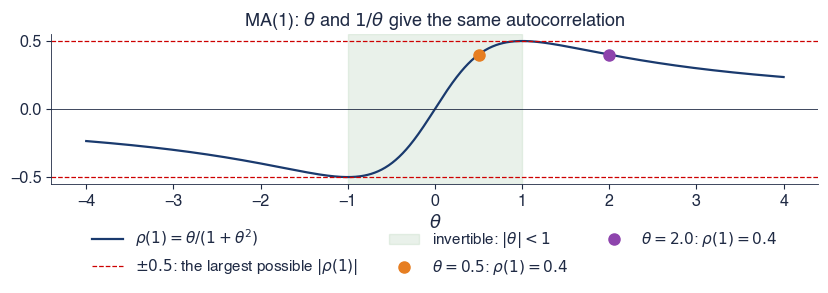

{'r05': 0.4, 'r2': 0.4}


In [6]:
print(fig_ma1())
print(fig_ma1_rho())

![tsa_ch2_ma1](./tsa_ch2_ma1.png)

Output: `tsa_ch2_ma1.pdf`

![tsa_ch2_ma1_rho](./tsa_ch2_ma1_rho.png)

Output: `tsa_ch2_ma1_rho.pdf`